In [ ]:

# Clip tidal models to Cape Cod bounding box
import os
from eo_tides.utils import clip_models
from eo_tides.utils import list_models

available_models, supported_models = list_models(
    directory="tide_models/"
)
# Define bounding Box
bbox_capecod = [-70.451122, 41.172320, -69.578025, 42.198560]
print(os.getcwd())
clip_models(input_directory = "tide_models/",
            output_directory = "tide_models_clipped",
            model = "DTU23",
            bbox = bbox_capecod)

In [ ]:
# Get tide height data for Marconi Beach
import pandas as pd
from eo_tides.model import model_phases

start = "2024-10-23"
end = "2025-03-19"
tide_df= model_phases(
        x=-69.963189,
        y=41.896050, 
        time=pd.date_range(start, end, freq="15min"),
        model=["EOT20", "GOT5.5","GOT5.6","FES2022_extrapolated"],
        output_format = "wide",
        directory="tide_models_clipped/",
        return_tides = True,
)

tide_df["time"] = pd.date_range(start, end, freq="15min")

In [ ]:
# Print dataframe with added tide height data:
print(tide_df.head())

tide_df.to_csv(f"tidal_data_marconi_modelled_{start}-{end}.csv", index=False)

In [ ]:
import pandas as pd
df = pd.read_csv(f"tidal_data_marconi_modelled_{start}-{end}.csv",skiprows=1)
df = df.rename(columns={'Unnamed: 8': 'time'})
df['time'] = pd.to_datetime(df['time'])
print(df)
print(list(df.columns))

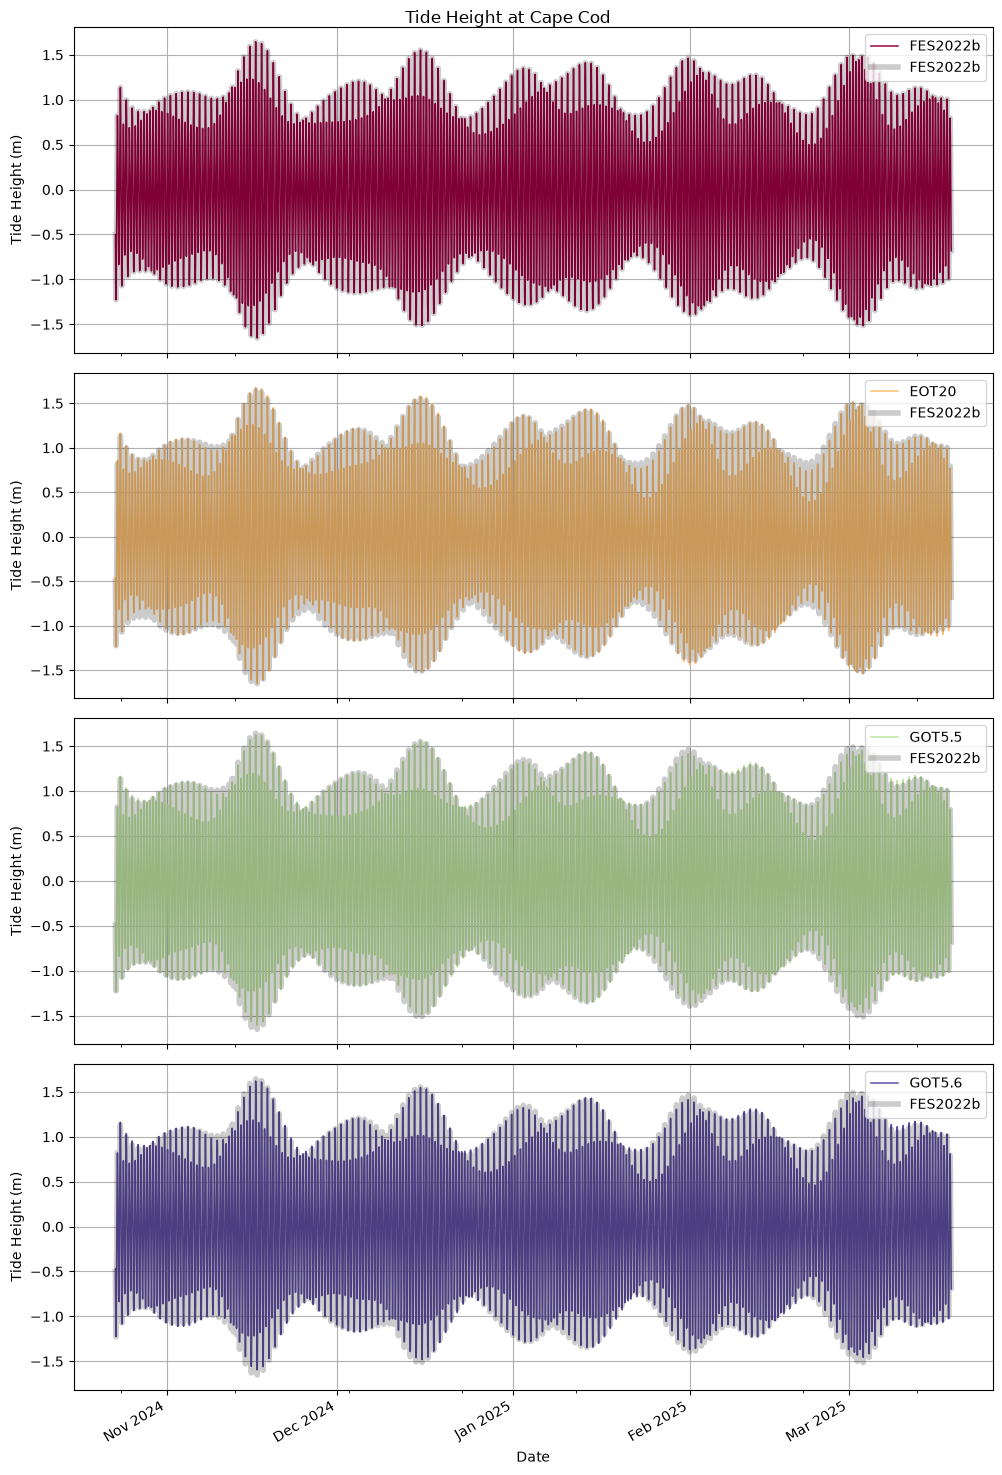

In [58]:
# Print outputs
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm

tide_columns= ["FES2022_extrapolated","EOT20","GOT5.5","GOT5.6"]

cmap = plt.get_cmap('Spectral')
axes = df.plot(figsize = (10, 15),
                    x = "time",
                    y = tide_columns,
                    title="Tide Height at Cape Cod",
                    ylabel="Tide Height (m)",
                    xlabel="Date",
                    subplots=True,
                    grid=True,
                    x_compat=True,
                    legend=False,
                    cmap = cmap,
                    linewidth = 1.1);
labels = ["FES2022b","FES2022b","EOT20","FES2022b","GOT5.5","FES2022b","GOT5.6","FES2022b"]
for i,ax in enumerate(axes):
    ax.plot(df["time"], 
            df["FES2022_extrapolated"],
            color = "black",
            linewidth=4,
            alpha = 0.2,
            zorder = 3,
           )
    start_idx = i * 2
    end_idx = start_idx + 2
    
    # Pass the list of strings to the legend
    ax.legend(labels[start_idx:end_idx],loc='upper right')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()
